# <span style="color:black; font-weight:bold;">Multi-Slices General Tutorial</span>
#### • <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
#### • <span style="color:black; font-weight:bold;">Date of Creation</span>: 03.16.2026
#### • <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 03.16.2026
#### • <span style="color:black; font-weight:bold;">Download</span>: Multi-Slice General Tutorial data used in the tutorial are available at [MERFISH.h5ad](https://drive.google.com/open?id=16UYRCGe6K5FAMYhoL2-2l7B8mYeCknQq&usp=drive_fs) , [STARmapPLUS.h5ad](https://drive.google.com/open?id=12cl4ToVZ8AosPshu_NVgmwegFUlY-Ol6&usp=drive_fs) and [CosMx.h5ad](https://drive.google.com/open?id=1qQRnL-zeWmzSZSlbxOiaKVtCFDB4xUW3&usp=drive_fs)
In this tutorial we apply SpaLP to 3 Sample Integration (CosMx/STARmapPLUS/MERFISH) of the Cross-platform Mouse Brain Sample Integration dataset

<span style="color:black; font-weight:bold;">The dataset have:</span>   
• <span style="color:black; font-weight:bold;">MERFISH</span>: 49,430 cells and 1122 genes   
• <span style="color:black; font-weight:bold;">STARmapPLUS</span>: 43,341 cells and 1022 genes  
• <span style="color:black; font-weight:bold;">CosMx</span>: 48,180 cells and 950 genes  
• <span style="color:black; font-weight:bold;">After integration Total</span>: 140,951 cells and 87 genes

In [1]:
from SpaLP.utils import prepare_inputs, set_seed,create_new_color_dict,Graph
from SpaLP.LP import SpatialLocalPooling
import torch
import warnings
import scanpy as sc
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import random

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(7)

## <span style="color:black; font-weight:bold;">Loading Multi-Slices data</span>

In [4]:
adata1=sc.read_h5ad("/home/dbj/SpaLA/Batch/MERFISH.h5ad")
adata1.obs['batch']='MERFISH'

adata2=sc.read_h5ad("/home/dbj/SpaLA/Batch/STARmapPLUS.h5ad")
adata2.obs['batch']='STARmapPLUS'

adata3=sc.read_h5ad("/home/dbj/SpaLA/Batch/CosMx.h5ad")
adata3.obs['batch']='CosMx'

## <span style="color:black; font-weight:bold;">Select the intersection gene panel</span>

In [5]:
adata_batch_list = [adata1,adata2,adata3]
adata = sc.concat(adata_batch_list, join="inner")

## <span style="color:black; font-weight:bold;">Data preprocessing</span>
We use [scanpy](https://scanpy.readthedocs.io/en/stable/installation.html) package to perform standard data processing.  
The standard processed expression matrix was saved in adata.obsm[<span style="color:red;">'feat'</span>] and used as input to the model.

In [6]:
adatas = []
for batch in adata.obs['batch'].unique():
    a = adata[adata.obs['batch'] == batch].copy()
    sc.pp.normalize_total(a,inplace=True)
    sc.pp.log1p(a)
    sc.pp.scale(a)
    adatas.append(a)

adata = sc.concat(adatas, join="inner")
adata.obsm['feat']=adata.X

### Randomly shuffling the adata

In [7]:
adata_list = [adata[adata.obs['batch'] == s] for s in adata.obs['batch'].unique()]
random.shuffle(adata_list)
del adata

In [8]:
adata = sc.concat(adata_list)

## <span style="color:black; font-weight:bold;">Compute Spatial Neighbor Graph and build the neighbor index matrix</span>
We compute the spatial Graph using 10 neighbors in Multi-Slices. k=10

In [9]:
graphs = []
for a in adata_list:
    graph = prepare_inputs(a, k=10,device=device)  #If insufficient GPU memory，set device='cpu'
    graphs.append(graph)

### <span style="color:black; font-weight:bold;">Initialize the SpaLP model</span> 

In [10]:
model = SpatialLocalPooling(in_channels=adata.obsm['feat'].shape[1], out_channels=32)

### <span style="color:black; font-weight:bold;">Model training (mode='multi-slices')</span>
epochs:training epochs (Default:100)  
lr:Learning rate (Default:1e-3)     
device:Model training device    
seed:Random seed (Default:7)  
mode:single-slice/multi-slices

In [11]:
model.Train(graph=graphs,epochs=100,lr=1e-3,device=device,seed=7,mode='multi-slices')

Training(multi-slices): 100%|██████████████████████████████████████| 100/100 [00:04<00:00, 24.55it/s, Epoch=99, Avg Loss=0.9338, PeakGPUmemory=0.97GB]


### <span style="color:black; font-weight:bold;">Output the reconstructed expression matrix and embedding (mode='multi-slices')</span>

In [12]:
reconstructed, embedding = model.get_embedding(graphs,mode='multi-slices')

In [13]:
adata.obsm['SpaLP']=embedding  
adata.layers['rec']=reconstructed  

### <span style="color:black; font-weight:bold;">Downstream analysis (Leiden and UMAP)</span>

In [15]:
%%time
sc.pp.neighbors(adata,use_rep='SpaLP')
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution=0.4,key_added='SpaLP')

IOStream.flush timed out
IOStream.flush timed out


CPU times: user 11min 24s, sys: 5min 16s, total: 16min 40s
Wall time: 6min


### <span style="color:black; font-weight:bold;">Multi-slices Integration embedding</span>

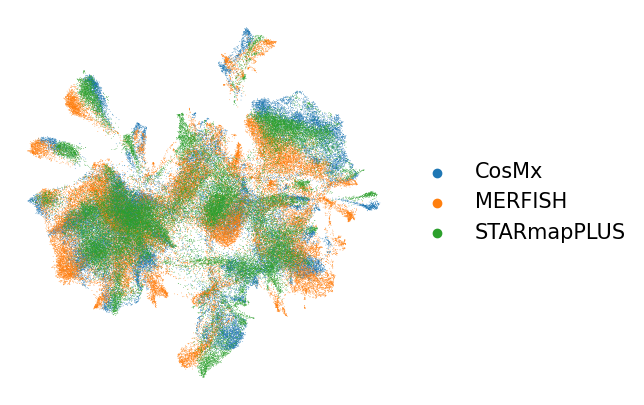

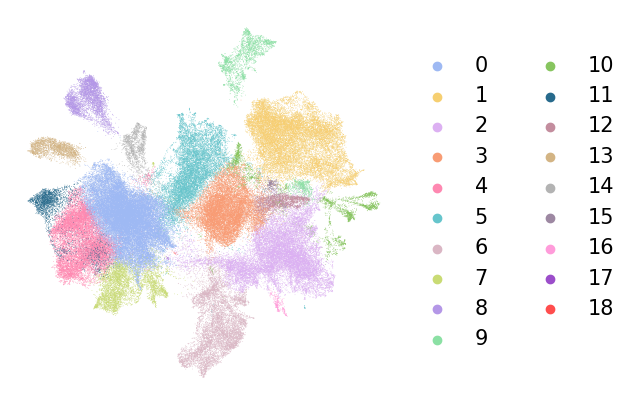

In [16]:
import matplotlib.pyplot as plt
import copy
plt.rcParams['figure.figsize'] = (5,5)
plt.rcParams['font.size'] = 15
sc.pl.umap(adata=adata,color='batch',title='',size=1,colorbar_loc=None,frameon=False)

latent_cluster_colors = create_new_color_dict(adata=adata,cat_key='SpaLP')
sc.pl.umap(adata=adata,color='SpaLP',title='',size=1,colorbar_loc=None,frameon=False,palette=latent_cluster_colors)

## <span style="color:black; font-weight:bold;">Multi-slices Niche identified by SpaLP</span>

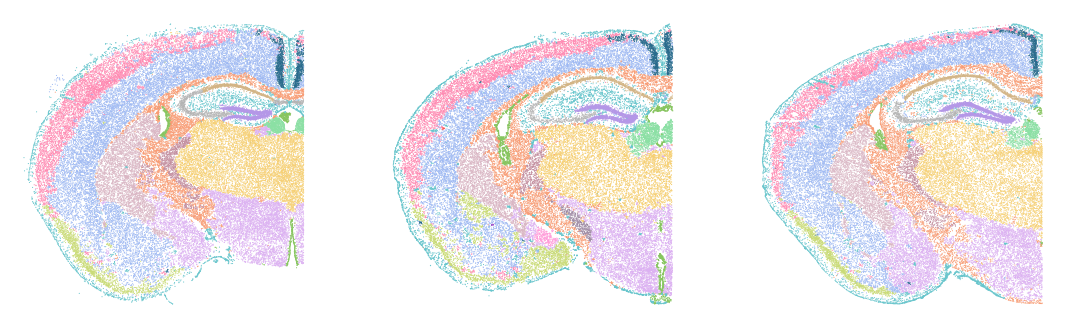

In [17]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['font.size'] = 15
latent_cluster_colors = create_new_color_dict(adata=adata,cat_key='SpaLP')
samples = adata.obs['batch'].unique().tolist()
fig, axs = plt.subplots(1, len(samples), figsize=(4.5 * len(samples), 4))
if len(samples) == 1:
    axs = [axs]
for idx, sample in enumerate(samples):
    sc.pl.embedding(adata=adata[adata.obs['batch'] == sample],basis='spatial',color=['SpaLP'],legend_loc=None,frameon=False,title='',palette=latent_cluster_colors,ax=axs[idx],show=False,size=2.5)

### <span style="color:black; font-weight:bold;">Original and reconstructed genes</span>

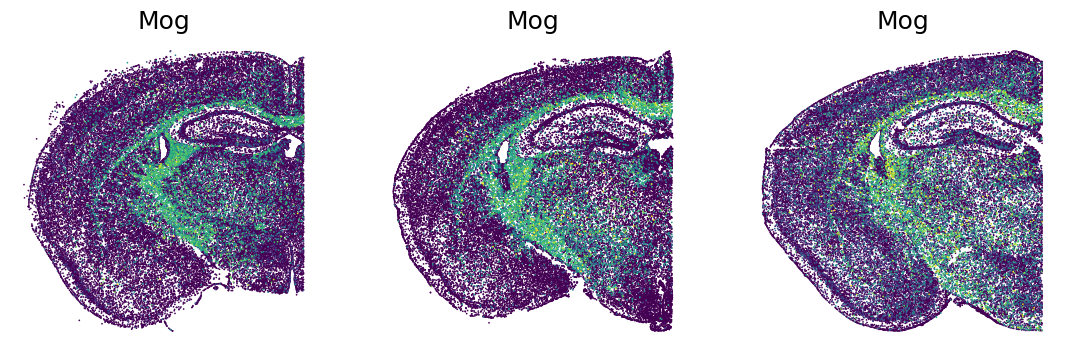

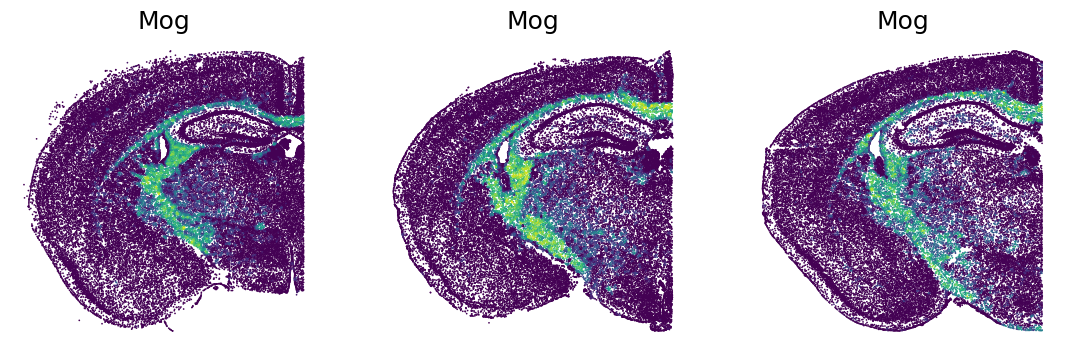

In [22]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['font.size'] = 15
samples = adata.obs['batch'].unique().tolist()
fig, axs = plt.subplots(1, len(samples), figsize=(4.5 * len(samples), 4))
if len(samples) == 1:
    axs = [axs]
for idx, sample in enumerate(samples):
    sc.pl.embedding(adata=adata[adata.obs['batch'] == sample],basis='spatial',color=['Mog'],legend_loc=None,frameon=False,colorbar_loc=None,ax=axs[idx],show=False,size=6)

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (10,8)
plt.rcParams['font.size'] = 15
samples = adata.obs['batch'].unique().tolist()
fig, axs = plt.subplots(1, len(samples), figsize=(4.5 * len(samples), 4))
if len(samples) == 1:
    axs = [axs]
for idx, sample in enumerate(samples):
    sc.pl.embedding(adata=adata[adata.obs['batch'] == sample],basis='spatial',color=['Mog'],legend_loc=None,frameon=False,colorbar_loc=None,ax=axs[idx],show=False,size=6,layer='rec')